# Task 3 — Car Price Prediction with Machine Learning

**OIBSIP — Data Science**

### Objective
Predict the selling price of a used car from relevant vehicle characteristics using regression models.

**Approach:** concise EDA → cleaning → feature engineering → outlier handling → feature selection → encoding → model training → evaluation → best-model analysis → final prediction.


## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")


## 2. Load and Understand the Dataset

In [2]:
df = pd.read_csv("/Users/sakshamchauhan/Downloads/Github/OIBSIP/OIBSIP-DataScience-Task3-Car_Price_Prediction/CAR_DETAILS_FROM_CAR_DEKHO.csv")

print("Shape:", df.shape)
display(df.head())
df.info()


Shape: (4340, 8)


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


<class 'pandas.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   name           4340 non-null   str  
 1   year           4340 non-null   int64
 2   selling_price  4340 non-null   int64
 3   km_driven      4340 non-null   int64
 4   fuel           4340 non-null   str  
 5   seller_type    4340 non-null   str  
 6   transmission   4340 non-null   str  
 7   owner          4340 non-null   str  
dtypes: int64(3), str(5)
memory usage: 271.4 KB


In [3]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

display(df.describe(include="all").T)


Missing values:
name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

Duplicate rows: 763


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
name,4340,1491,Maruti Swift Dzire VDI,69,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,4340.0,NaN,NaN,NaN,2013.090783,4.215344,1992.0,2011.0,2014.0,2016.0,2020.0
selling_price,4340.0,NaN,NaN,NaN,504127.311751,578548.736139,20000.0,208749.75,350000.0,600000.0,8900000.0
km_driven,4340.0,NaN,NaN,NaN,66215.777419,46644.102194,1.0,35000.0,60000.0,90000.0,806599.0
fuel,4340,5,Diesel,2153,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seller_type,4340,3,Individual,3244,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transmission,4340,2,Manual,3892,NaN,NaN,NaN,NaN,NaN,NaN,NaN
owner,4340,5,First Owner,2832,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Data Cleaning and Feature Engineering

Remove duplicate records, standardize text values, then create **car_age**, **brand**, and a compact **model_name** feature. Raw `name` and `year` will not be used directly in the model.

In [4]:
df.columns = df.columns.str.strip()

for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype(str).str.strip()

df = df.drop_duplicates().reset_index(drop=True)

CURRENT_YEAR = 2026
df["car_age"] = CURRENT_YEAR - df["year"]
df["brand"] = df["name"].str.split().str[0]
df["model_name"] = df["name"].str.split().str[1].fillna("Unknown")

print("Shape after cleaning:", df.shape)
display(df[["name", "year", "car_age", "brand", "model_name"]].head())


Shape after cleaning: (3577, 11)


,name,year,car_age,brand,model_name
0,Maruti 800 AC,2007,19,Maruti,800
1,Maruti Wagon R LXI Minor,2007,19,Maruti,Wagon
2,Hyundai Verna 1.6 SX,2012,14,Hyundai,Verna
3,Datsun RediGO T Option,2017,9,Datsun,RediGO
4,Honda Amaze VX i-DTEC,2014,12,Honda,Amaze


## 4. Outlier Handling

The target has a strong right tail. Extreme selling prices and implausibly high mileage can dominate regression errors, so IQR filtering is applied. The purpose is to reduce extreme observations, not to force a perfectly normal distribution.

In [5]:
def iqr_filter(data, column):
    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)
    iqr = q3 - q1
    lower = max(0, q1 - 1.5 * iqr)
    upper = q3 + 1.5 * iqr
    return data[data[column].between(lower, upper)].copy(), lower, upper

before = len(df)

df, price_low, price_high = iqr_filter(df, "selling_price")
df, km_low, km_high = iqr_filter(df, "km_driven")

print("Rows removed:", before - len(df))
print("Final shape:", df.shape)
print(f"Selling-price bounds: {price_low:,.0f} to {price_high:,.0f}")
print(f"Kilometres bounds: {km_low:,.0f} to {km_high:,.0f}")


Rows removed: 290
Final shape: (3287, 11)
Selling-price bounds: 0 to 1,200,000
Kilometres bounds: 0 to 166,018


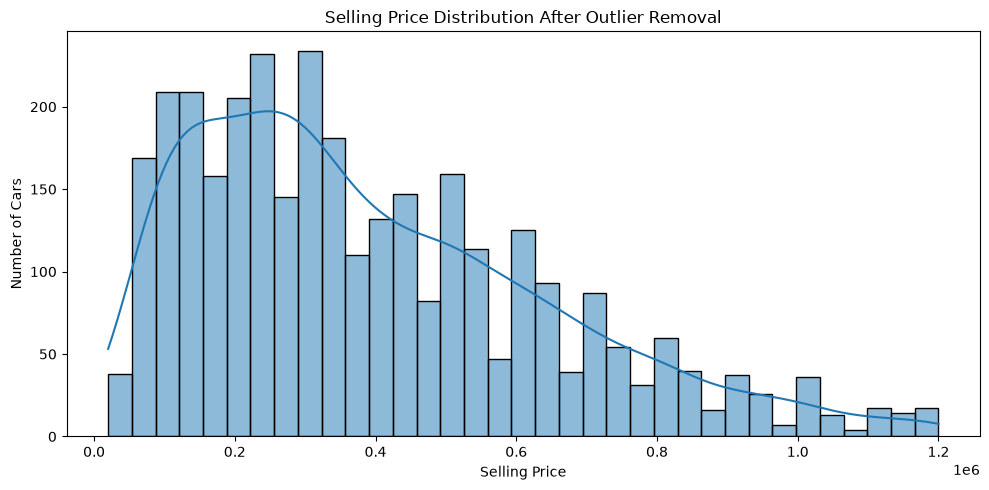

In [6]:
plt.figure(figsize=(10, 5))
sns.histplot(df["selling_price"], bins=35, kde=True)
plt.title("Selling Price Distribution After Outlier Removal")
plt.xlabel("Selling Price")
plt.ylabel("Number of Cars")
plt.tight_layout()
plt.show()


## 5. Exploratory Data Analysis

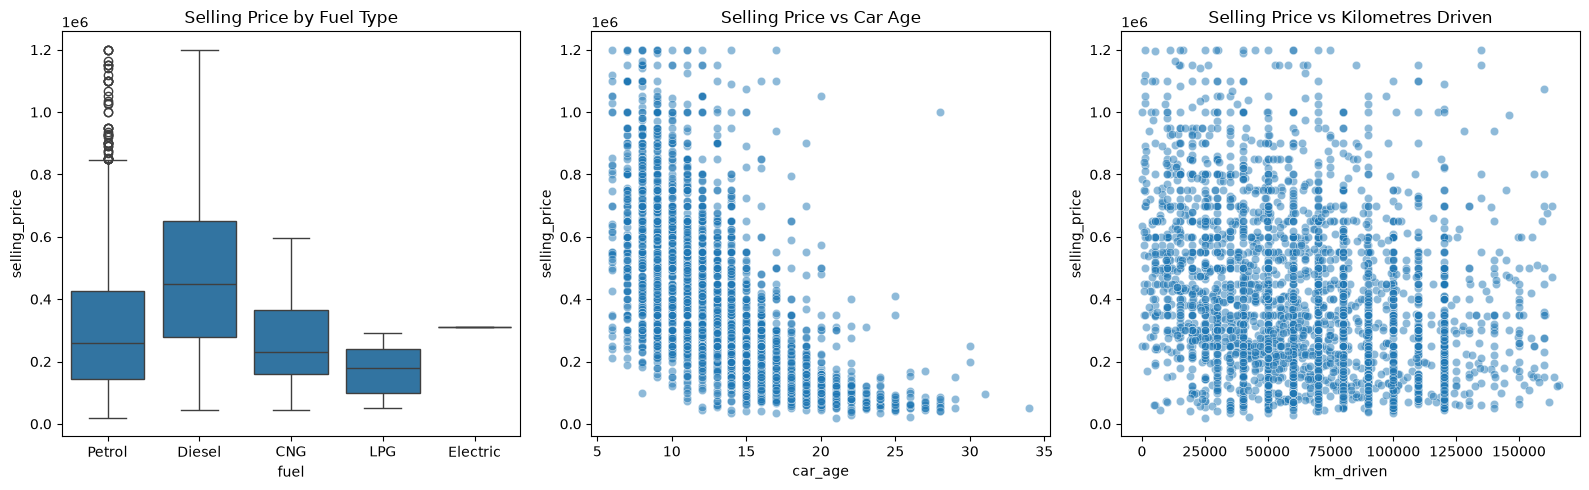

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(data=df, x="fuel", y="selling_price", ax=axes[0])
axes[0].set_title("Selling Price by Fuel Type")

sns.scatterplot(data=df, x="car_age", y="selling_price", alpha=0.5, ax=axes[1])
axes[1].set_title("Selling Price vs Car Age")

sns.scatterplot(data=df, x="km_driven", y="selling_price", alpha=0.5, ax=axes[2])
axes[2].set_title("Selling Price vs Kilometres Driven")

plt.tight_layout()
plt.show()


## 6. Correlation Analysis

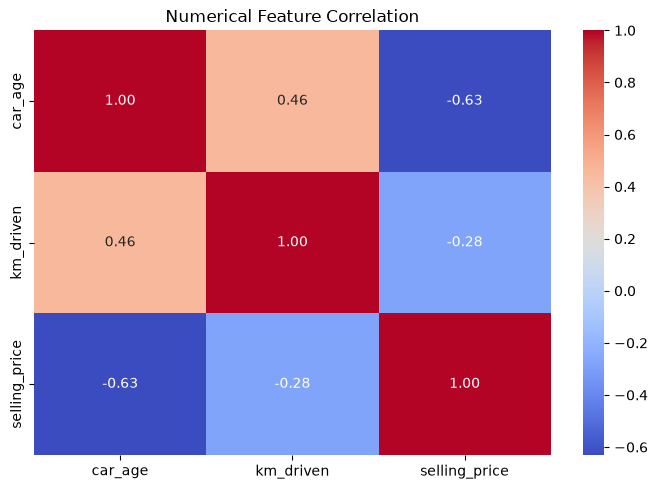

In [8]:
numeric_cols = ["car_age", "km_driven", "selling_price"]

plt.figure(figsize=(7, 5))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Numerical Feature Correlation")
plt.tight_layout()
plt.show()


## 7. Feature Selection

Keep features that have a meaningful relationship with used-car price and match the task objective. Drop raw `name`, `year`, and `owner` from the final model. `name` is replaced by `brand` and `model_name`; `year` is replaced by `car_age`.

In [9]:
features = [
    "car_age",
    "km_driven",
    "fuel",
    "transmission",
    "brand",
    "model_name"
]

target = "selling_price"

model_df = df[features + [target]].copy()

# Group very rare model names to reduce noisy one-hot categories.
model_counts = model_df["model_name"].value_counts()
model_df["model_name"] = model_df["model_name"].where(
    model_df["model_name"].map(model_counts) >= 10,
    "Other"
)

X = model_df[features]
y = model_df[target]

print("Selected features:", features)
print("X shape:", X.shape)


Selected features: ['car_age', 'km_driven', 'fuel', 'transmission', 'brand', 'model_name']
X shape: (3287, 6)


## 8. Train-Test Split and Encoding

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

categorical_features = ["fuel", "transmission", "brand", "model_name"]
numeric_features = ["car_age", "km_driven"]

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="passthrough"
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)


Training set: (2629, 6)
Testing set: (658, 6)


## 9. Train Regression Models

Three models are used: Linear Regression as the baseline, Random Forest for nonlinear relationships, and Extra Trees as another strong tree-based ensemble.

In [11]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),
    "Extra Trees": ExtraTreesRegressor(
        n_estimators=300,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )
}

trained_models = {}
predictions = {}
results = []

for name, model in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    pred = pipeline.predict(X_test)

    trained_models[name] = pipeline
    predictions[name] = pred

    results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "R2 Score": r2_score(y_test, pred)
    })

results = pd.DataFrame(results).set_index("Model")
display(results.round(3))


,MAE,RMSE,R2 Score
Model,,,
Linear Regression,92798.822,126713.983,0.766
Random Forest,76897.774,113673.335,0.812
Extra Trees,72584.077,108775.458,0.828


## 10. Model Comparison

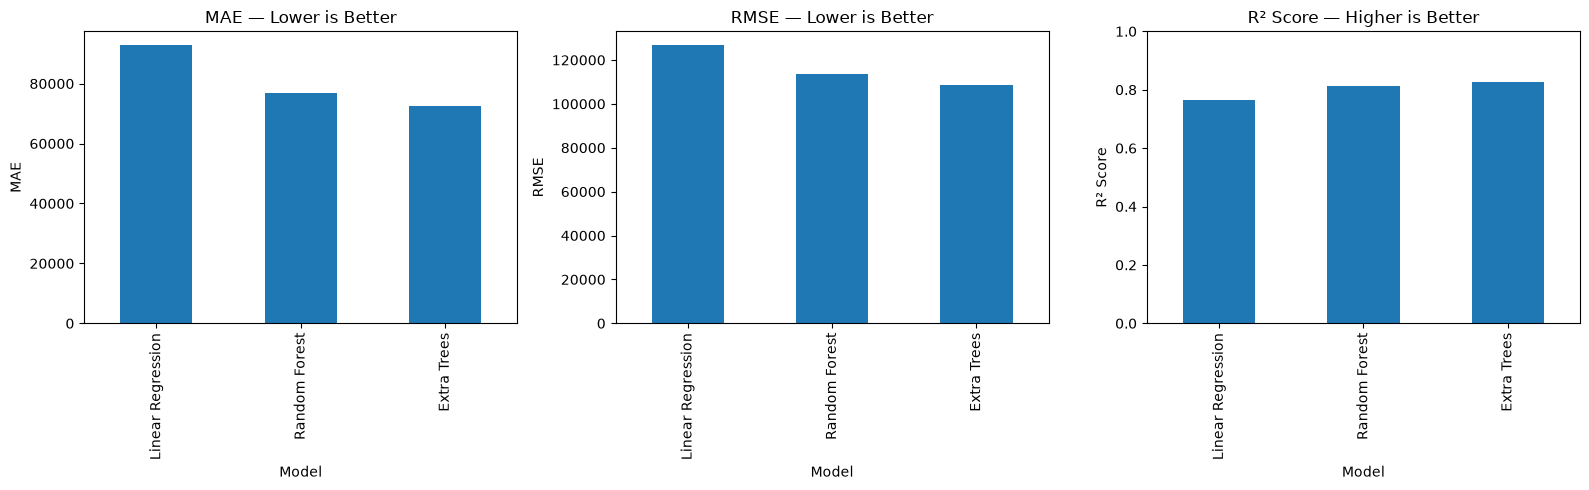

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

results["MAE"].plot(kind="bar", ax=axes[0], title="MAE — Lower is Better")
axes[0].set_ylabel("MAE")

results["RMSE"].plot(kind="bar", ax=axes[1], title="RMSE — Lower is Better")
axes[1].set_ylabel("RMSE")

results["R2 Score"].plot(kind="bar", ax=axes[2], title="R² Score — Higher is Better")
axes[2].set_ylabel("R² Score")
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()


## 11. Select the Best Model

In [13]:
best_model_name = results["R2 Score"].idxmax()
best_model = trained_models[best_model_name]
best_predictions = predictions[best_model_name]

print("Best Model:", best_model_name)
print("R² Score:", round(results.loc[best_model_name, "R2 Score"], 4))
print("MAE:", round(results.loc[best_model_name, "MAE"], 2))
print("RMSE:", round(results.loc[best_model_name, "RMSE"], 2))


Best Model: Extra Trees
R² Score: 0.8279
MAE: 72584.08
RMSE: 108775.46


## 12. Actual vs Predicted Prices

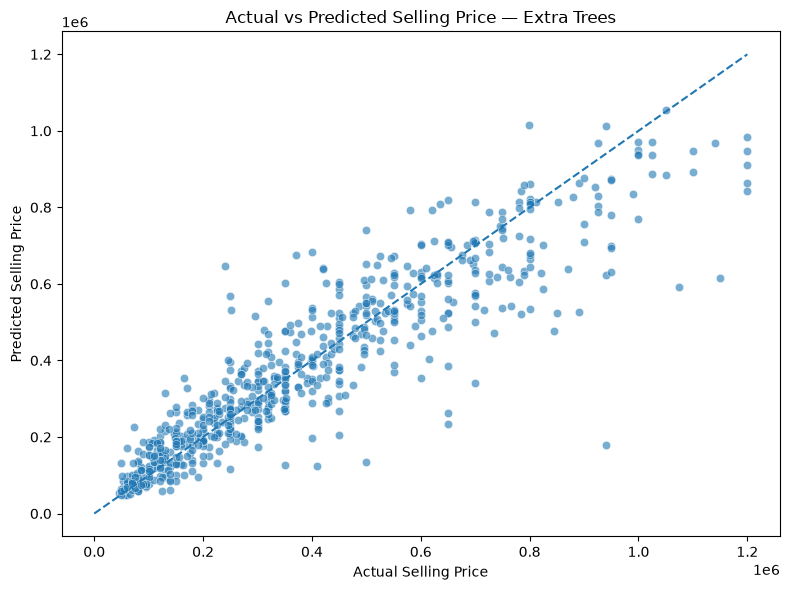

In [14]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=best_predictions, alpha=0.6)

limit = max(y_test.max(), best_predictions.max())
plt.plot([0, limit], [0, limit], "--")

plt.title(f"Actual vs Predicted Selling Price — {best_model_name}")
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.tight_layout()
plt.show()


## 13. Residual Analysis

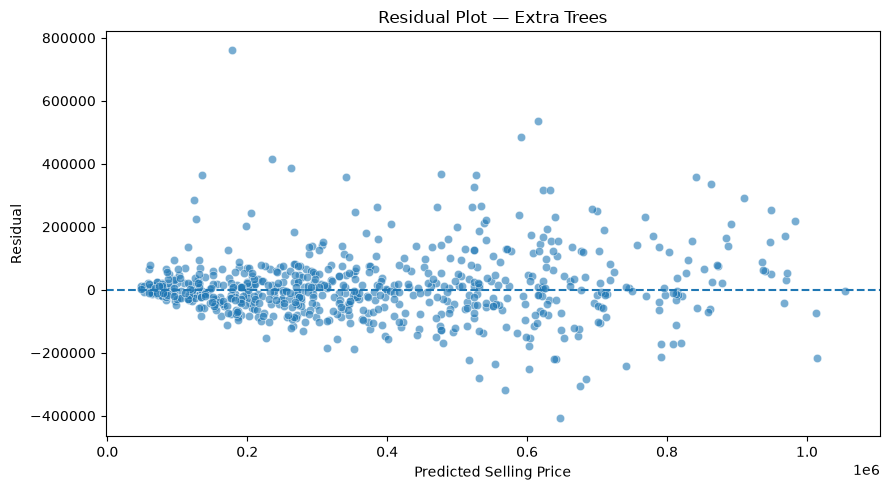

In [15]:
residuals = y_test - best_predictions

plt.figure(figsize=(9, 5))
sns.scatterplot(x=best_predictions, y=residuals, alpha=0.6)
plt.axhline(0, linestyle="--")
plt.title(f"Residual Plot — {best_model_name}")
plt.xlabel("Predicted Selling Price")
plt.ylabel("Residual")
plt.tight_layout()
plt.show()


## 14. Feature Importance

For the best tree-based model, feature importance is aggregated back to the original feature groups so the chart remains readable instead of showing hundreds of one-hot encoded columns.

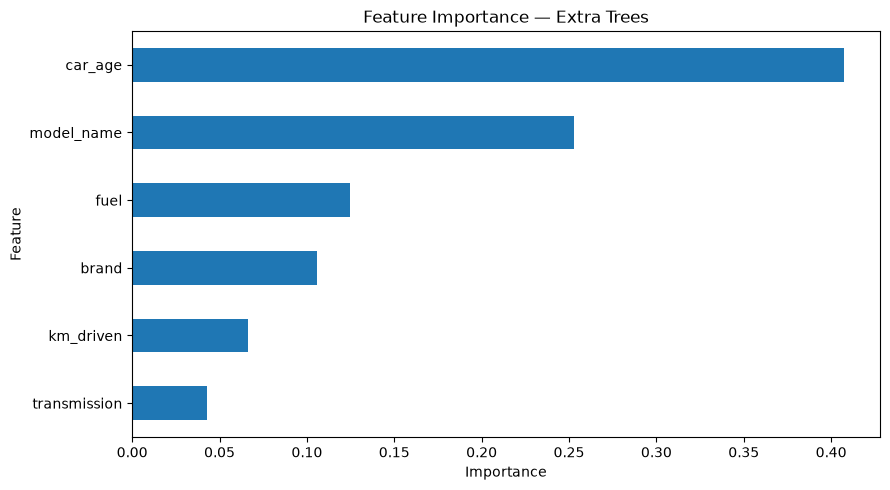

,Importance
Feature Group,
car_age,0.407571
model_name,0.253027
fuel,0.124473
brand,0.105651
km_driven,0.066440
transmission,0.042838


In [16]:
if best_model_name in ["Random Forest", "Extra Trees"]:
    fitted_preprocessor = best_model.named_steps["preprocessor"]
    estimator = best_model.named_steps["model"]

    encoded_names = list(
        fitted_preprocessor.named_transformers_["categorical"]
        .get_feature_names_out(categorical_features)
    )
    feature_names = encoded_names + numeric_features
    importances = estimator.feature_importances_

    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    })

    def feature_group(name):
        if name.startswith("fuel_"):
            return "fuel"
        if name.startswith("transmission_"):
            return "transmission"
        if name.startswith("brand_"):
            return "brand"
        if name.startswith("model_name_"):
            return "model_name"
        return name

    importance_df["Feature Group"] = importance_df["Feature"].map(feature_group)

    grouped_importance = (
        importance_df.groupby("Feature Group")["Importance"]
        .sum()
        .sort_values(ascending=True)
    )

    plt.figure(figsize=(9, 5))
    grouped_importance.plot(kind="barh")
    plt.title(f"Feature Importance — {best_model_name}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

    display(grouped_importance.sort_values(ascending=False).to_frame("Importance"))
else:
    print("Feature importance is not available for Linear Regression.")


## 15. Final Prediction

In [17]:
new_car = pd.DataFrame({
    "car_age": [5],
    "km_driven": [50000],
    "fuel": ["Petrol"],
    "transmission": ["Manual"],
    "brand": ["Maruti"],
    "model_name": ["Swift"]
})

predicted_price = best_model.predict(new_car)[0]

print(f"Predicted Selling Price: ₹{predicted_price:,.0f}")


Predicted Selling Price: ₹554,479


## 16. Conclusion

The project followed a compact machine-learning pipeline:

- Cleaned duplicates and inconsistent text values.
- Engineered `car_age`, `brand`, and `model_name`.
- Removed extreme selling-price and mileage observations using the IQR method.
- Removed raw/redundant columns from the modeling dataset.
- Used One-Hot Encoding for categorical variables.
- Compared Linear Regression, Random Forest, and Extra Trees.
- Evaluated models using MAE, RMSE, and R².
- Selected the model with the highest R² score.
- Analysed predictions, residuals, and feature importance.
- Used the final model to predict the price of a new used car.

**Note:** Removing extreme observations can improve the fit on the cleaned dataset, but it should always be reported because those observations may represent legitimate high-value vehicles rather than data errors.
